<a href="https://colab.research.google.com/github/khuranakhurana430-alt/Test/blob/main/Man_Women(CNN)%20Classification_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#                                          FIXED CODES FOR KAGGLE IMPORT

!mkdir -p ~/.kaggle
!cp KAGGLE.json ~/.kaggle/
!chmod 600 ~/.kaggle/KAGGLE.json

In [ ]:
#                                          CLI KEY COPIED FORM KAGGLE DOWNLOADS.

In [ ]:
!kaggle datasets download -d snmahsa/human-images-dataset-men-and-women

Dataset URL: https://www.kaggle.com/datasets/snmahsa/human-images-dataset-men-and-women
License(s): MIT
human-images-dataset-men-and-women.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#                                     FIX CODES TO EXTRACT ZIPFILE

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/human-images-dataset-men-and-women.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
#                                             REQUIRED IMPORTS

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as keras
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,BatchNormalization,Dropout,Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#                                     IMPORTING DATA USING GENERTORS

In [ ]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/gender_dataset',
    labels='inferred',
    label_mode='int',
    subset='training',
    validation_split=0.2,
    seed=123,
    batch_size=32,
    image_size=(256,256)
)

val_ds=keras.utils.image_dataset_from_directory(
    directory='/content/gender_dataset',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    validation_split=0.2,
    seed=123,
    subset='validation',
    image_size=(256,256)
)

Found 1668 files belonging to 2 classes.
Using 1335 files for training.
Found 1668 files belonging to 2 classes.
Using 333 files for validation.


In [ ]:
#                                         DEFAULT FUNTION

In [ ]:
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
val_ds=val_ds.map(process)

In [ ]:
#                                        MODEL SELECTION AND TUNING

In [ ]:
model=Sequential()

In [ ]:
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(125,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

model.summary()



/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 125)  │        36,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 125)  │           500 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 125)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        72,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 125)    │        36,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 125)    │           500 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        72,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,25

 Total params: 278,723 (1.06 MB)

 Trainable params: 277,839 (1.06 MB)

 Non-trainable params: 884 (3.45 KB)

In [ ]:
#                                   COMPILE THE MODEL

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#                                   TRAIN AND FIT THE MODEL

In [ ]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds,callbacks=[EarlyStopping(patience=3)])

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8772 - loss: 0.3057 - val_accuracy: 0.7297 - val_loss: 0.5787
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8921 - loss: 0.2595 - val_accuracy: 0.5646 - val_loss: 0.8517
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9228 - loss: 0.2128 - val_accuracy: 0.7117 - val_loss: 0.5533
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9371 - loss: 0.1681 - val_accuracy: 0.6667 - val_loss: 0.9155
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9348 - loss: 0.1696 - val_accuracy: 0.6276 - val_loss: 1.2846
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9633 - loss: 0.1005 - val_accuracy: 0.7628 - val_loss: 0.9698


In [ ]:
#                                      MATPLOTLIB (PYPLOT)

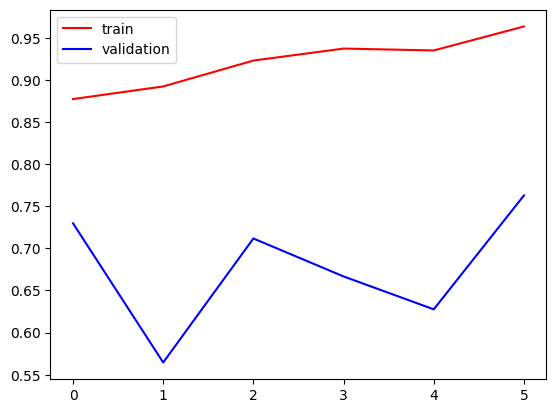

In [ ]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

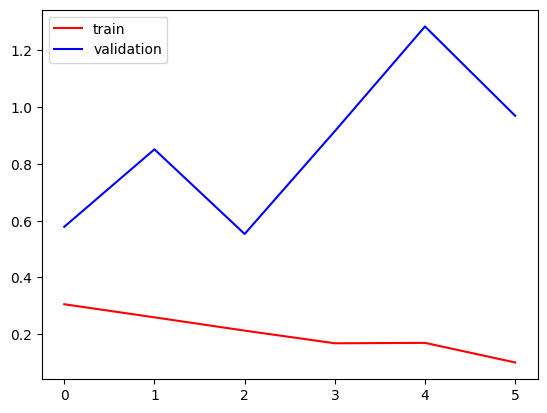

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy %:", test_accuracy * 100)

NameError: name 'model' is not defined